In [111]:
# IMPORT
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files
import os



Saving Hamong tani_pages-to-jpg-0047.jpg to Hamong tani_pages-to-jpg-0047 (19).jpg
Dimensi gambar: 2350x1482


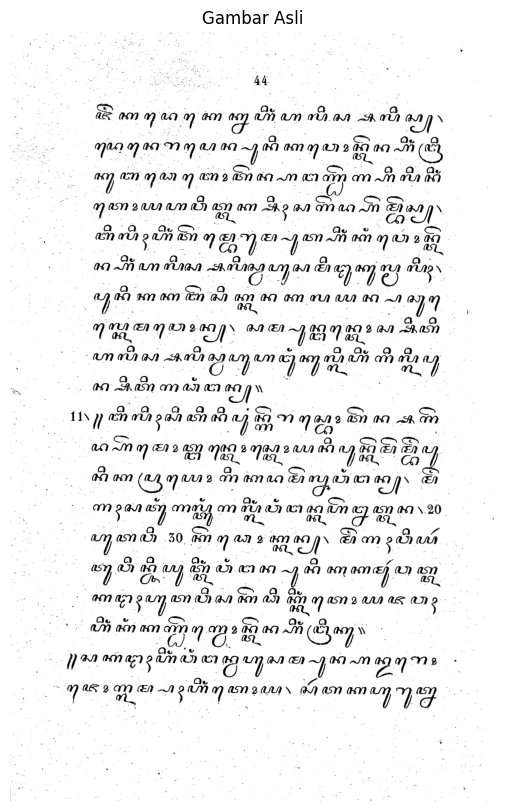

In [112]:
# LOAD IMAGE
uploaded = files.upload()
path = list(uploaded.keys())[0]

img = cv2.imread(path)
rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
h, w = img.shape[:2]

# Menampilkan Gambar
print(f"Dimensi gambar: {H}x{W}")
plt.figure(figsize=(10, 10))
plt.imshow(img_rgb)
plt.title("Gambar Asli")
plt.axis('off')
plt.show()

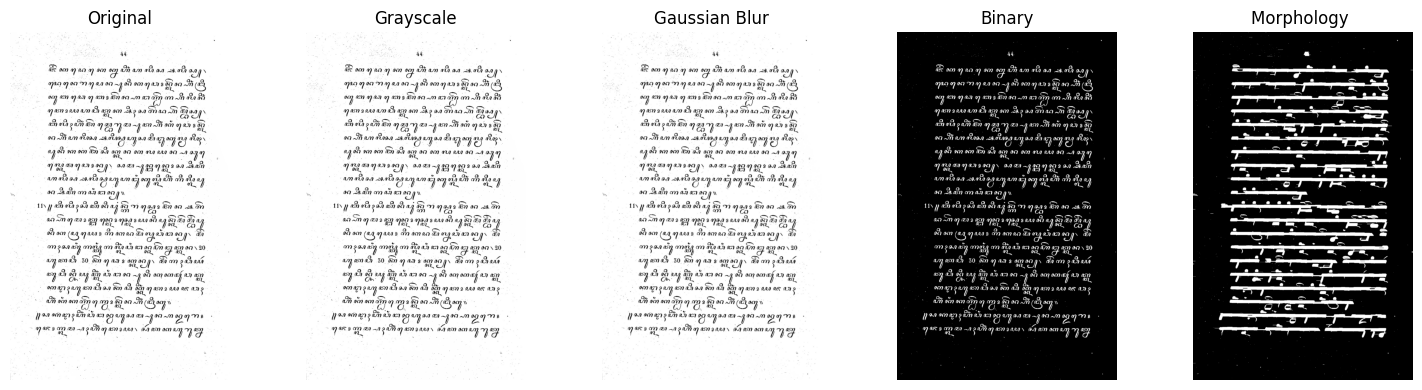

In [132]:
# PREPROCESS
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)  # mengubah gambar dari format BGR ke grayscale (abu-abu)

# Gaussian Blur
denoise = cv2.GaussianBlur(gray, (3,3), 0)  # mengurangi noise pada gambar menggunakan Gaussian Blur dengan kernel 3x3

# threshold
_, bw = cv2.threshold(  # melakukan thresholding untuk mengubah gambar menjadi biner (hitam-putih)
    denoise, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

# morphology horizontal
kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (30,1))  # membuat kernel berbentuk persegi panjang horizontal (lebar 30, tinggi 1)
clean = cv2.morphologyEx(bw, cv2.MORPH_CLOSE, kernel)

# VISUALISASI PREPROCESSING
plt.figure(figsize=(15,4))

# Original
plt.subplot(1,5,1)
plt.imshow(rgb)
plt.title("Original")
plt.axis('off')

# Grayscale
plt.subplot(1,5,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")
plt.axis('off')

# Blur
plt.subplot(1,5,3)
plt.imshow(denoise, cmap='gray')
plt.title("Gaussian Blur")
plt.axis('off')

# Binary
plt.subplot(1,5,4)
plt.imshow(bw, cmap='gray')
plt.title("Binary")
plt.axis('off')

# Morphology
plt.subplot(1,5,5)
plt.imshow(clean, cmap='gray')
plt.title("Morphology ")
plt.axis('off')

plt.tight_layout()
plt.show()

In [133]:
# PROJECTION
projection = np.sum(clean == 255, axis=1)

k = 20  # ukuran window untuk smoothing (jumlah data yang dirata-ratakan)
kernel_avg = np.ones(k) / k  # membuat kernel rata-rata (moving average) dengan nilai yang dijumlahkan = 1
smooth = np.convolve(projection, kernel_avg, mode='same')  # melakukan smoothing pada data projection menggunakan konvolusi



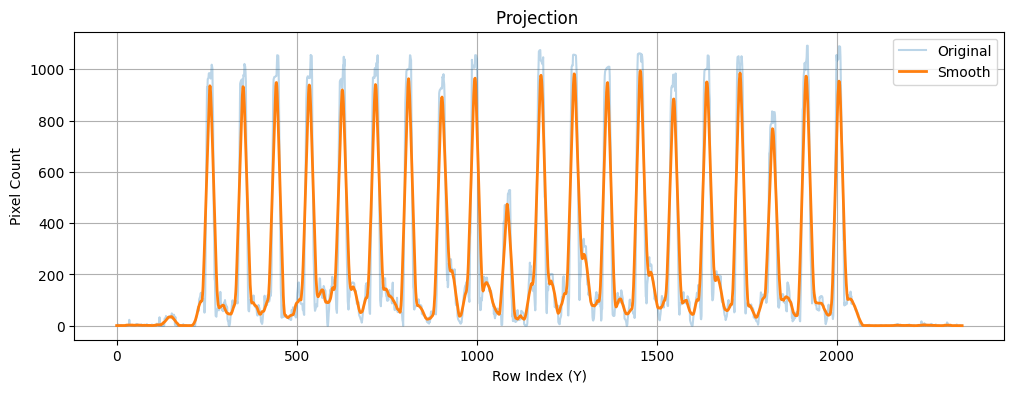

In [131]:
# VISUALISASI
plt.figure(figsize=(12,4))

plt.plot(np.arange(h), projection, alpha=0.3, label='Original')
plt.plot(np.arange(h), smooth, linewidth=2, label='Smooth')

plt.title("Projection ")
plt.xlabel("Row Index (Y)")
plt.ylabel("Pixel Count")

plt.legend()
plt.grid()
plt.show()



In [116]:
# PEAK DETECTION
candidates = []

for i in range(2, len(smooth)-2):
    window = smooth[i-2:i+3]

    # kondisi lokal maksimum
    if smooth[i] == max(window) and smooth[i] > np.mean(smooth):
        candidates.append(i)

candidates = np.array(candidates)

# ranking berdasarkan tinggi peak
if len(candidates) > 21:
    vals = smooth[candidates]
    top_idx = np.argsort(vals)[-21:]
    candidates = candidates[top_idx]

peaks = np.sort(candidates)

print("Jumlah baris:", len(peaks))



Jumlah baris: 21


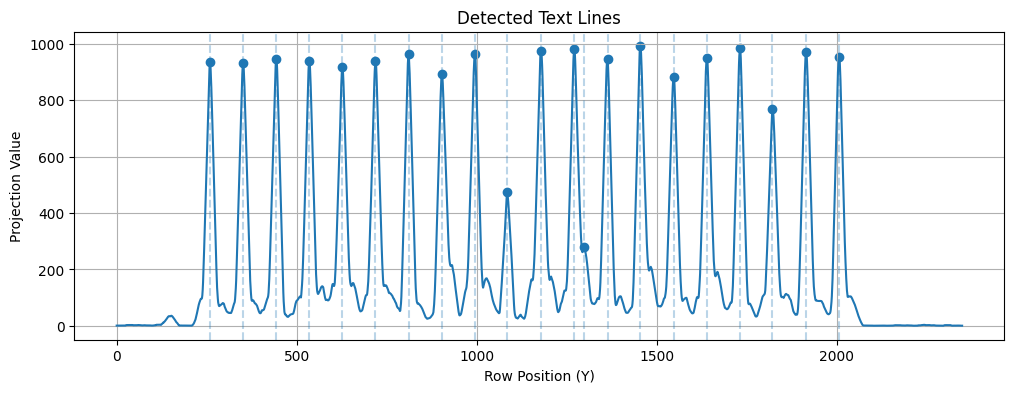

In [117]:
# VISUALISASI PEAK
plt.figure(figsize=(12,4))

plt.plot(np.arange(h), smooth)
plt.scatter(peaks, smooth[peaks])

# garis vertikal untuk tiap peak
for p in peaks:
    plt.axvline(p, linestyle='--', alpha=0.3)

plt.title("Detected Text Lines")
plt.xlabel("Row Position (Y)")
plt.ylabel("Projection Value")

plt.grid()
plt.show()


In [118]:
# BOUNDARY ANTAR BARIS
cuts = [0]

for i in range(len(peaks)-1):
    mid = int((peaks[i] + peaks[i+1]) / 2)
    cuts.append(mid)

cuts.append(h)



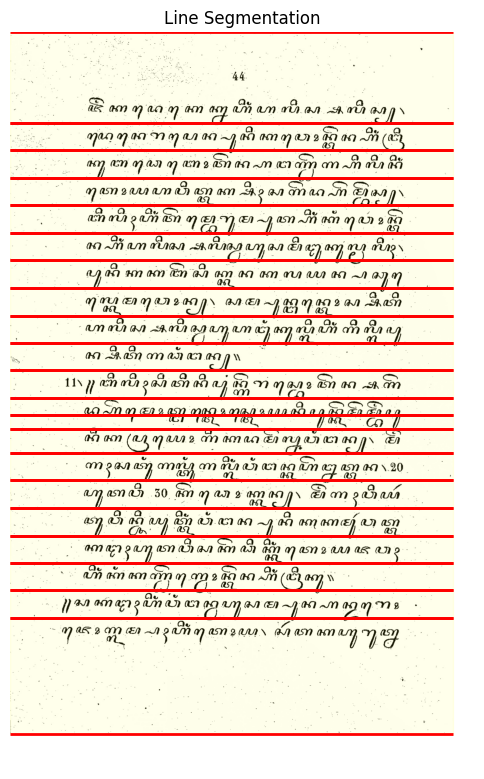

In [119]:
# VISUALISASI SEGMENTASI
plt.figure(figsize=(6,10))
plt.imshow(rgb)

for i in range(len(cuts)-1):
    y1, y2 = cuts[i], cuts[i+1]

    plt.hlines([y1, y2], 0, w, colors='red', linewidth=2)
    plt.fill_betweenx([y1, y2], 0, w, color='yellow', alpha=0.08)

plt.title("Line Segmentation")
plt.axis('off')
plt.show()



In [120]:
# CROP HASIL
os.makedirs("hasil_baris", exist_ok=True)

lines = []

for i in range(len(cuts)-1):
    y1, y2 = cuts[i], cuts[i+1]
    seg = rgb[y1:y2, :]
    lines.append(seg)

    cv2.imwrite(
        f"hasil_baris/line_{i+1}.png",
        cv2.cvtColor(seg, cv2.COLOR_RGB2BGR)
    )



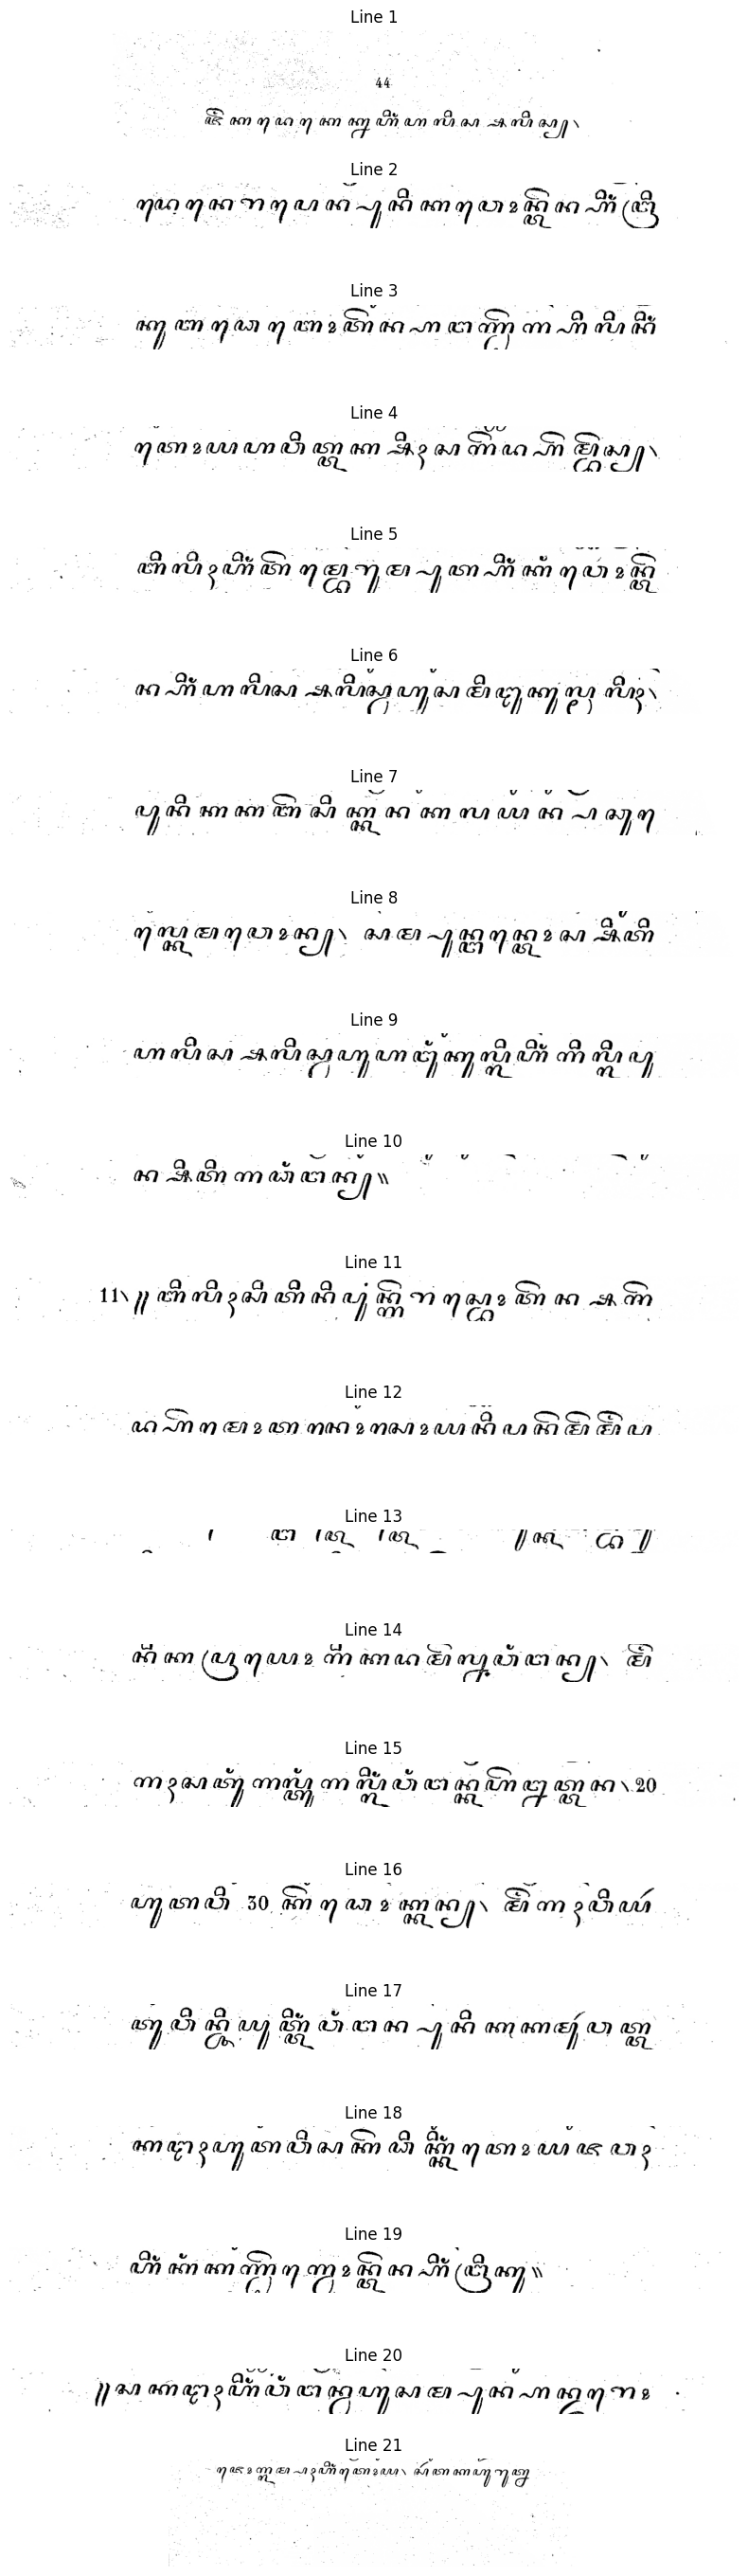

In [121]:
# TAMPILKAN HASIL
plt.figure(figsize=(8, len(lines)*1.3))

for i, l in enumerate(lines):
    plt.subplot(len(lines),1,i+1)
    plt.imshow(l)
    plt.title(f"Line {i+1}")
    plt.axis('off')

plt.tight_layout()
plt.show()



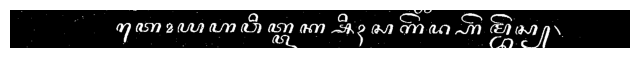

In [122]:
# CONTOH 1 BARIS
sample = lines[3]

gray_line = cv2.cvtColor(sample, cv2.COLOR_RGB2GRAY)
_, bin_line = cv2.threshold(
    gray_line, 0, 255,
    cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU
)

plt.figure(figsize=(8,2))
plt.imshow(bin_line, cmap='gray')
plt.axis('off')
plt.show()